## **Import Libraries**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## **Reading datase**

In [3]:
# Read data from csv file
df = pd.read_csv('D:/Data Analysis project/Marketing Campaign Performance Analysis/marketing_campaign_dataset.csv')

## ****Data Exploration Analysis - EDA****

In [4]:
# Show data top 5
df.head(5)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [5]:
# Show data bottom 5
df.tail(5)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
199995,199996,TechCorp,Display,All Ages,30 days,Google Ads,0.06,"$18,365.00",2.84,Chicago,German,858,5988,1,Tech Enthusiasts,2021-12-07
199996,199997,DataTech Solutions,Email,Men 25-34,15 days,Facebook,0.02,"$8,168.00",4.14,Chicago,Spanish,228,3068,7,Foodies,2021-12-08
199997,199998,DataTech Solutions,Social Media,Men 18-24,45 days,Website,0.05,"$13,397.00",3.25,New York,Mandarin,723,9548,3,Tech Enthusiasts,2021-12-09
199998,199999,Innovate Industries,Influencer,All Ages,30 days,YouTube,0.10,"$18,508.00",3.86,Houston,French,528,2763,1,Foodies,2021-12-10
199999,200000,Innovate Industries,Social Media,Women 35-44,45 days,Google Ads,0.01,"$13,835.00",6.64,Chicago,Spanish,924,7287,8,Tech Enthusiasts,2021-12-11


In [6]:
# Check null value in the dataset
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [7]:
# Check not-null value and datatype in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [8]:
# Check duplicate record in the dataset
duplicated_data = df[df.duplicated()].sort_values('Campaign_ID', ascending=True)

In [9]:
# Show duplicate value
duplicated_data

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date


## **Data Cleaning**

In [10]:
# Strip any leading/trailing spaces in column names
df.columns = df.columns.str.strip()

In [11]:
# Convert Campaign_ID column from float to object
df['Campaign_ID'] = df['Campaign_ID'].astype(str)

In [12]:
# Remove $ from number in Acquisition_Cost column
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$', '', regex=False)

In [13]:
# Remove , from number in Acquisition_Cost column
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace(',', '', regex=False)

In [14]:
# Convert Acquisition_Cost column from object to float
df['Acquisition_Cost'] = df['Acquisition_Cost'].astype(float)

In [15]:
# Convert into a correct datatype
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [16]:
# Show data after cleaned and converted into correct format of datatype
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [17]:
# Check not-null and datatype again after converted
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  object        
 1   Company           200000 non-null  object        
 2   Campaign_Type     200000 non-null  object        
 3   Target_Audience   200000 non-null  object        
 4   Duration          200000 non-null  object        
 5   Channel_Used      200000 non-null  object        
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  object        
 10  Language          200000 non-null  object        
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Cust

In [18]:
# Check unique value of Company column
df['Company'].unique()

array(['Innovate Industries', 'NexGen Systems', 'Alpha Innovations',
       'DataTech Solutions', 'TechCorp'], dtype=object)

In [19]:
# Check unique value of Campaign_Type column
df['Campaign_Type'].unique()

array(['Email', 'Influencer', 'Display', 'Search', 'Social Media'],
      dtype=object)

In [20]:
# Check unique value of Target_Audience
df['Target_Audience'].unique()

array(['Men 18-24', 'Women 35-44', 'Men 25-34', 'All Ages', 'Women 25-34'],
      dtype=object)

In [21]:
# Check unique value of Duration
df['Duration'].unique()

array(['30 days', '60 days', '15 days', '45 days'], dtype=object)

In [22]:
# Check unique value of Channel_Used
df['Channel_Used'].unique()

array(['Google Ads', 'YouTube', 'Instagram', 'Website', 'Facebook',
       'Email'], dtype=object)

In [23]:
# Check unique value of Location
df['Location'].unique()

array(['Chicago', 'New York', 'Los Angeles', 'Miami', 'Houston'],
      dtype=object)

In [24]:
# Check unique value of Customer_Segment
df['Customer_Segment'].unique()

array(['Health & Wellness', 'Fashionistas', 'Outdoor Adventurers',
       'Foodies', 'Tech Enthusiasts'], dtype=object)

In [ ]:
# Check Descriptive Statistic
df.describe()

##  **Finding the Insights by Data Visualization**

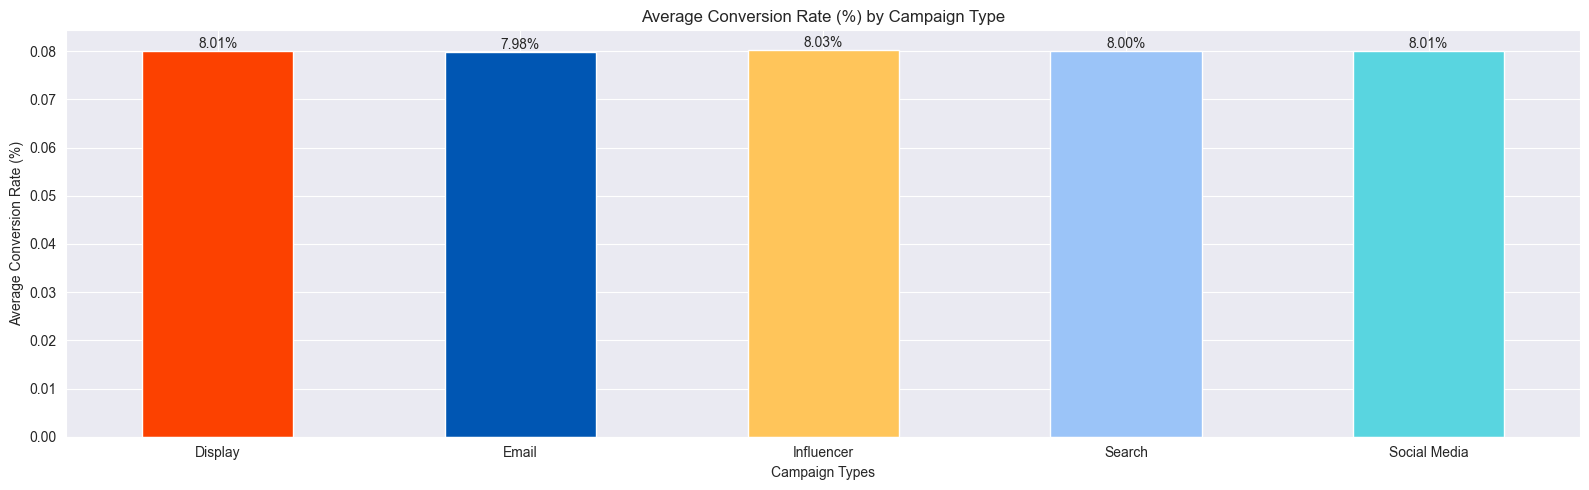

In [30]:
##  **Conversion Rates Analysis**
# Average Conversion Rate across different Campaign Type
avg_conversion_rate_by_campaign_type = df.groupby(['Campaign_Type'])['Conversion_Rate'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_conversion_rate_by_campaign_type.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Conversion Rate (%) by Campaign Type')
plt.xlabel('Campaign Types')
plt.xticks(rotation=0)
plt.ylabel('Average Conversion Rate (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:,.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points')

# Show the plot
plt.tight_layout()
plt.show()

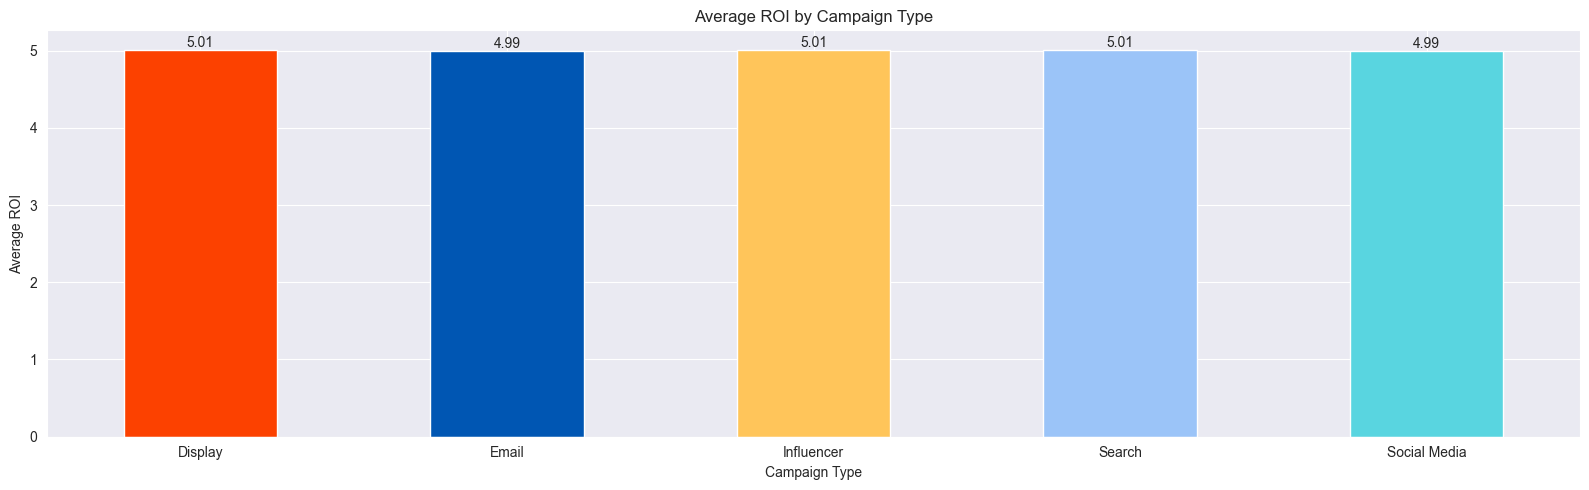

In [31]:
 ##  **Return On Investment (ROI) Analysis**
 # Average Return on Investment (ROI) for each Campaign Type
avg_roi_by_campaign_type = df.groupby(['Campaign_Type'])['ROI'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_roi_by_campaign_type.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average ROI by Campaign Type')
plt.xlabel('Campaign Type')
plt.xticks(rotation=0)
plt.ylabel('Average ROI')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:,.3}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

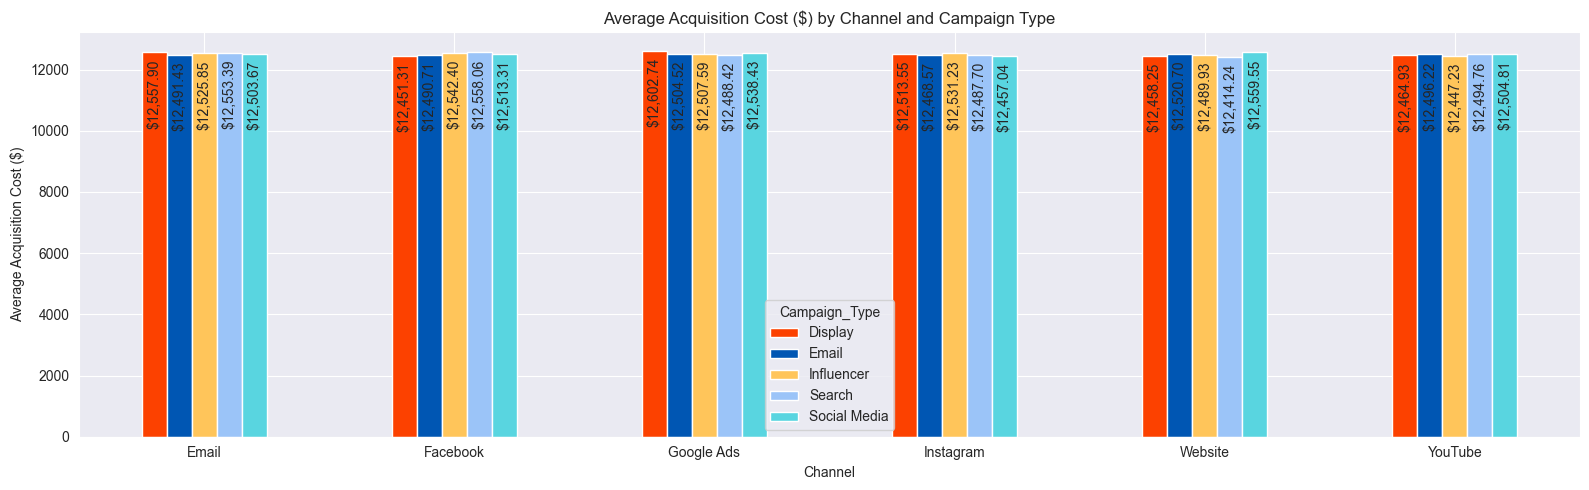

In [32]:
##  ** Acquisition Costs Analysis **
# Average Acquisition Cost across different Channel and Campaign Type
avg_acquisition_cost_by_channel_and_campaign_type = df.groupby(['Channel_Used', 'Campaign_Type'])['Acquisition_Cost'].mean().unstack()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_acquisition_cost_by_channel_and_campaign_type.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Acquisition Cost ($) by Channel and Campaign Type')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Average Acquisition Cost ($)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'${height:,.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, -30),
                  textcoords='offset points',
                  rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

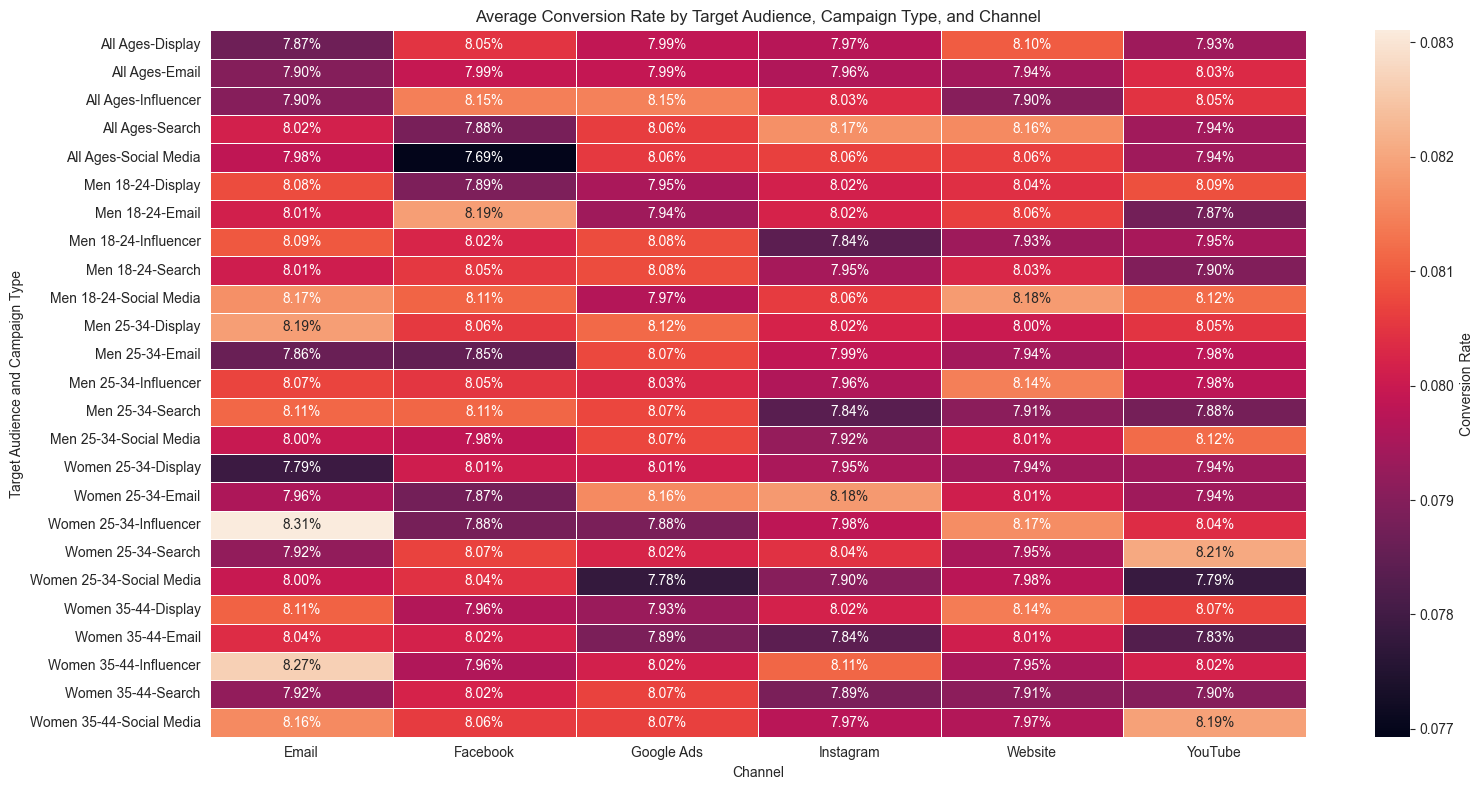

In [33]:
##  ** Target Audienece Analysis **
# Average Conversion Rate by Target Audience, Campaign Type, and Channel
avg_conversion_rate_by_3_fields = df.groupby(['Target_Audience', 'Campaign_Type', 'Channel_Used'])['Conversion_Rate'].mean().unstack()

# Plot data as a heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(avg_conversion_rate_by_3_fields, annot=True, fmt='.2%', linewidths=0.5, cbar_kws={'label': 'Conversion Rate'})

# Add title and labels
plt.title('Average Conversion Rate by Target Audience, Campaign Type, and Channel')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Target Audience and Campaign Type')

# Show plot
plt.tight_layout()
plt.show()


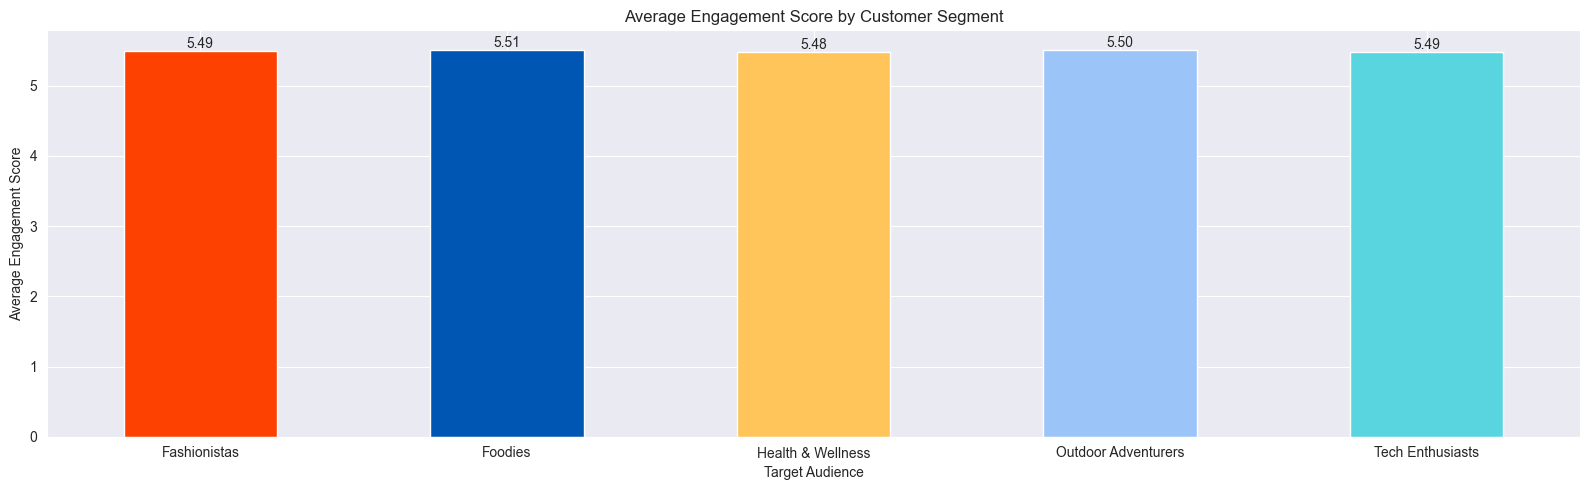

In [34]:
##  ** Customer Segment Analysis **
# Average Engagement Socre by Customer Segment
avg_engagement_score_by_customer_segment = df.groupby('Customer_Segment')['Engagement_Score'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_engagement_score_by_customer_segment.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Engagement Score by Customer Segment')
plt.xlabel('Target Audience')
plt.xticks(rotation=0)
plt.ylabel('Average Engagement Score')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

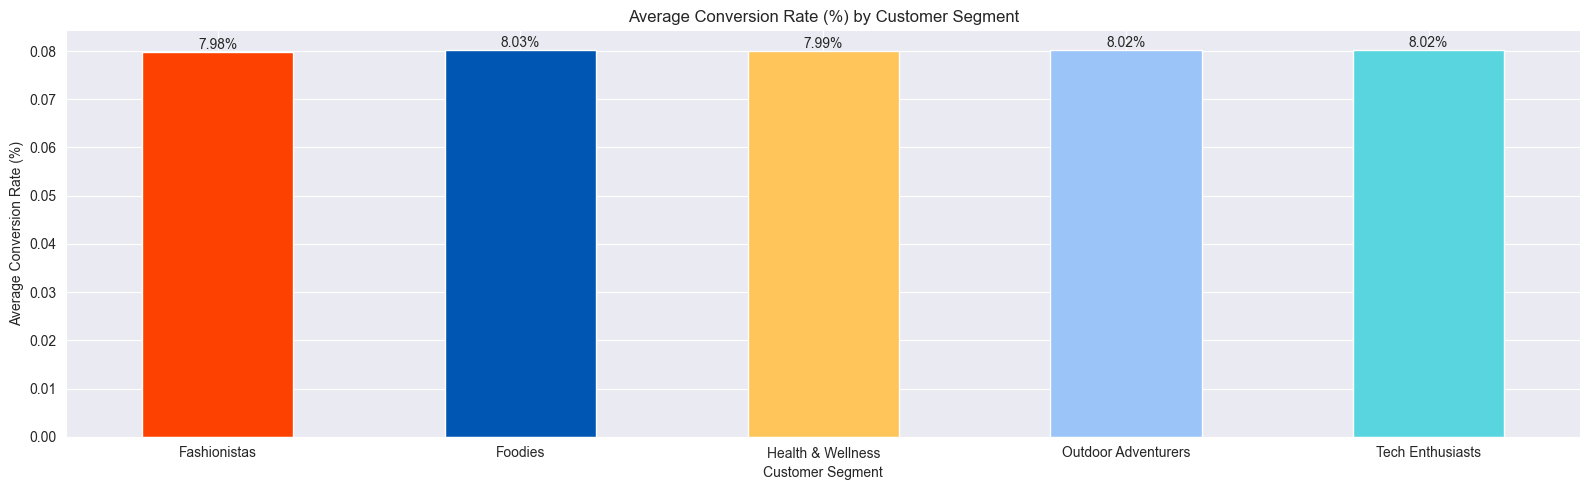

In [35]:
# Average Conversion Rate by Customer Segment
avg_conversion_rate_by_customer_segment = df.groupby('Customer_Segment')['Conversion_Rate'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_conversion_rate_by_customer_segment.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Conversion Rate (%) by Customer Segment')
plt.xlabel('Customer Segment')
plt.xticks(rotation=0)
plt.ylabel('Average Conversion Rate (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

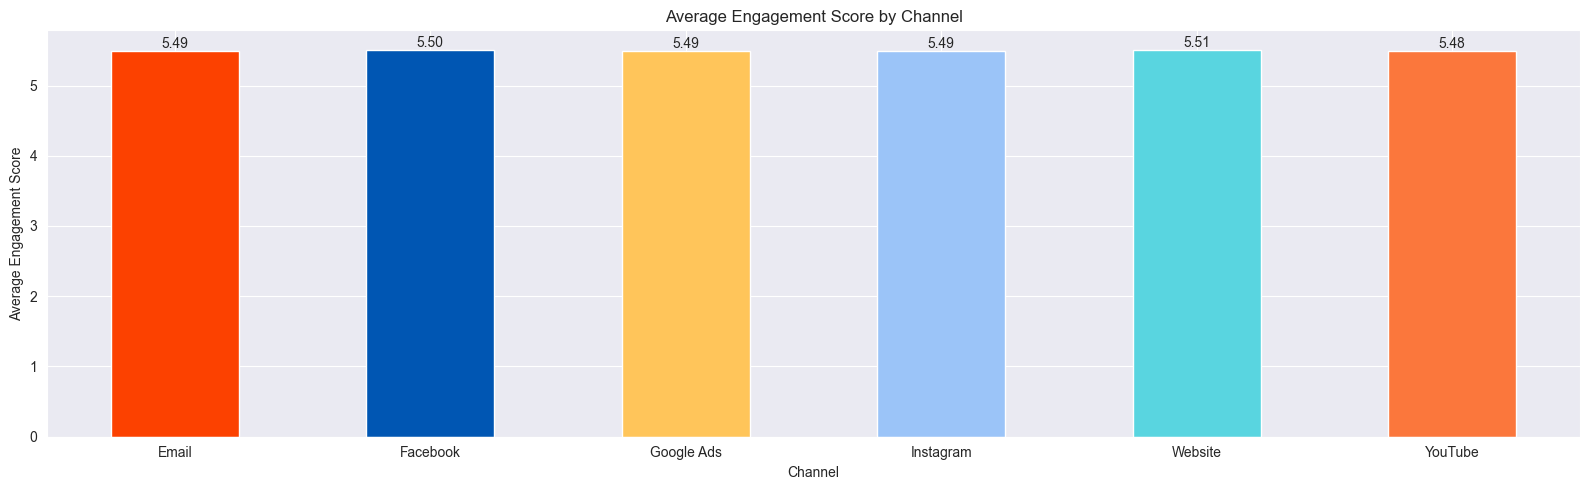

In [36]:
 ##  ** Channels Used Analysis **
 # Average Engagement Socre by Channel
avg_engagement_score_by_channel = df.groupby('Channel_Used')['Engagement_Score'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_engagement_score_by_channel.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Engagement Score by Channel')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Average Engagement Score')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

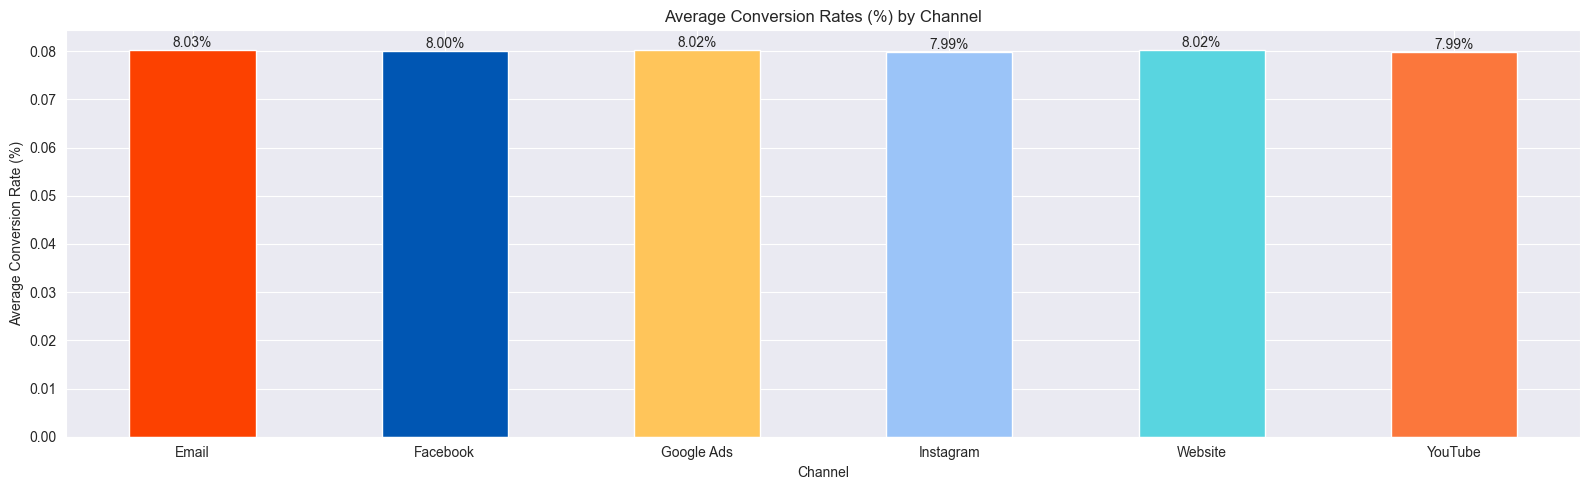

In [37]:
# Average Conversion Rates by Channel
avg_conversion_rate_by_channel = df.groupby('Channel_Used')['Conversion_Rate'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_conversion_rate_by_channel.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Conversion Rates (%) by Channel')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Average Conversion Rate (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

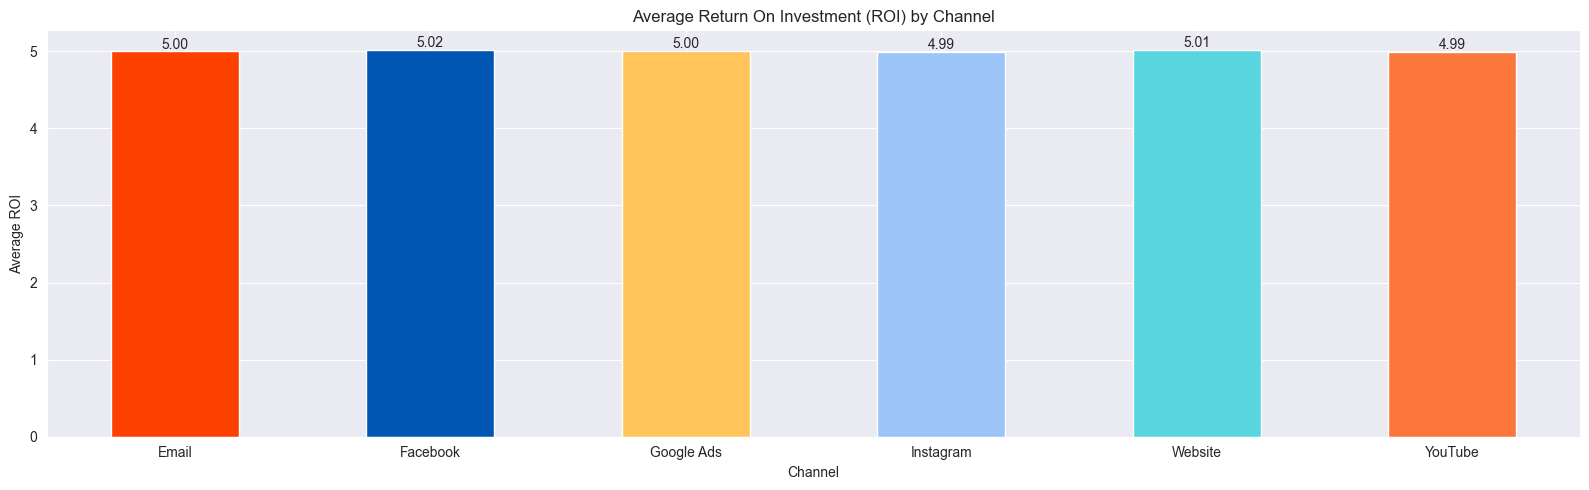

In [38]:
# Average ROI by Channel
avg_roi_by_channel = df.groupby('Channel_Used')['ROI'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_roi_by_channel.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Return On Investment (ROI) by Channel')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Average ROI')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

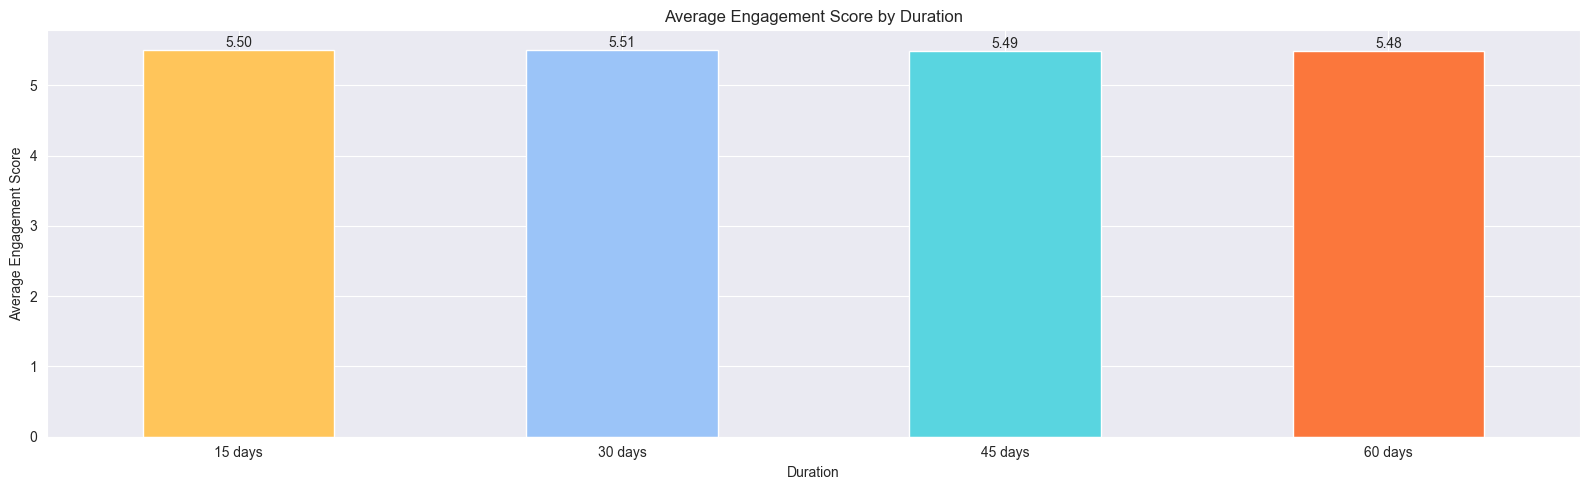

In [39]:
##  ** Duration Impact Analysis **
# Average Engagement Score by Duration
avg_engagement_score_by_duration = df.groupby('Duration')['Engagement_Score'].mean()
colors = ['#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']
# colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_engagement_score_by_duration.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Engagement Score by Duration')
plt.xlabel('Duration')
plt.xticks(rotation=0)
plt.ylabel('Average Engagement Score')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

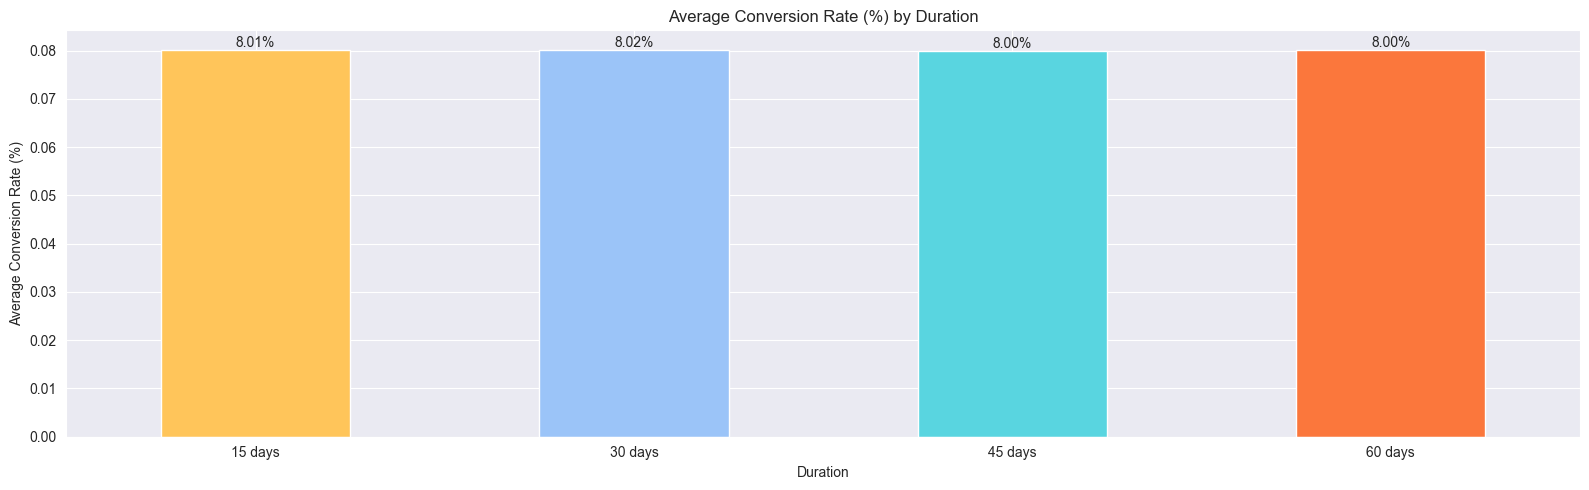

In [40]:
# Average Conversion Rates by Duration
avg_conversion_rate_by_duration = df.groupby('Duration')['Conversion_Rate'].mean()
colors = ['#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_conversion_rate_by_duration.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Conversion Rate (%) by Duration')
plt.xlabel('Duration')
plt.xticks(rotation=0)
plt.ylabel('Average Conversion Rate (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

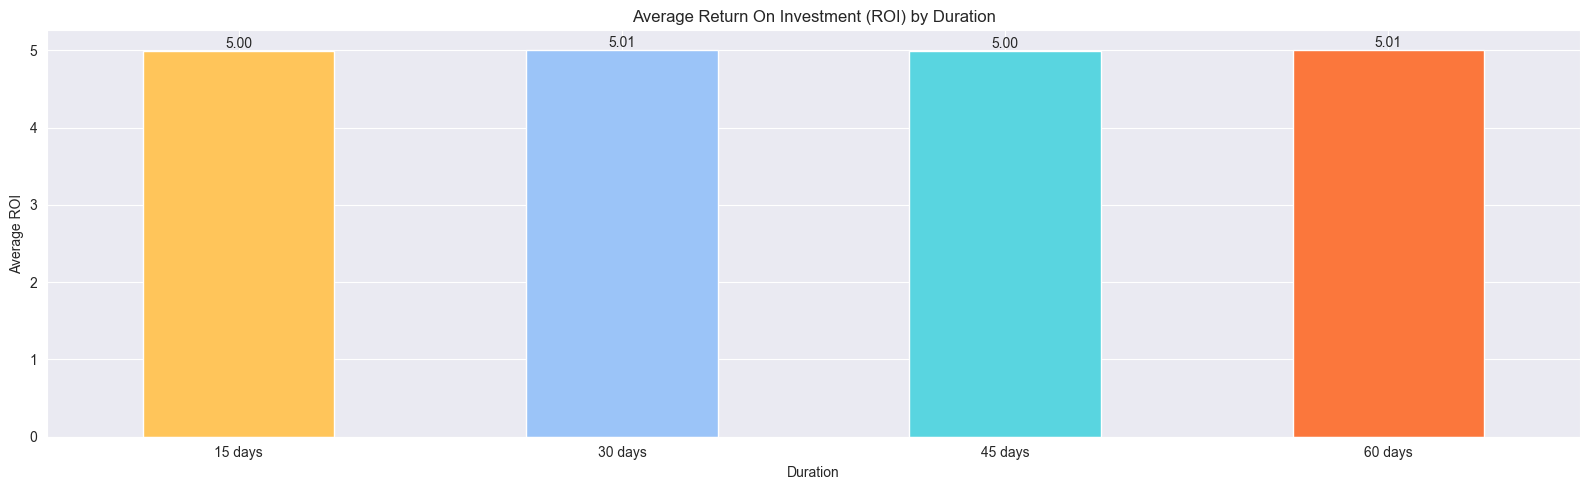

In [41]:
# Average ROI by Duration
avg_roi_by_duration = df.groupby('Duration')['ROI'].mean()
colors = ['#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_roi_by_duration.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Return On Investment (ROI) by Duration')
plt.xlabel('Duration')
plt.xticks(rotation=0)
plt.ylabel('Average ROI')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

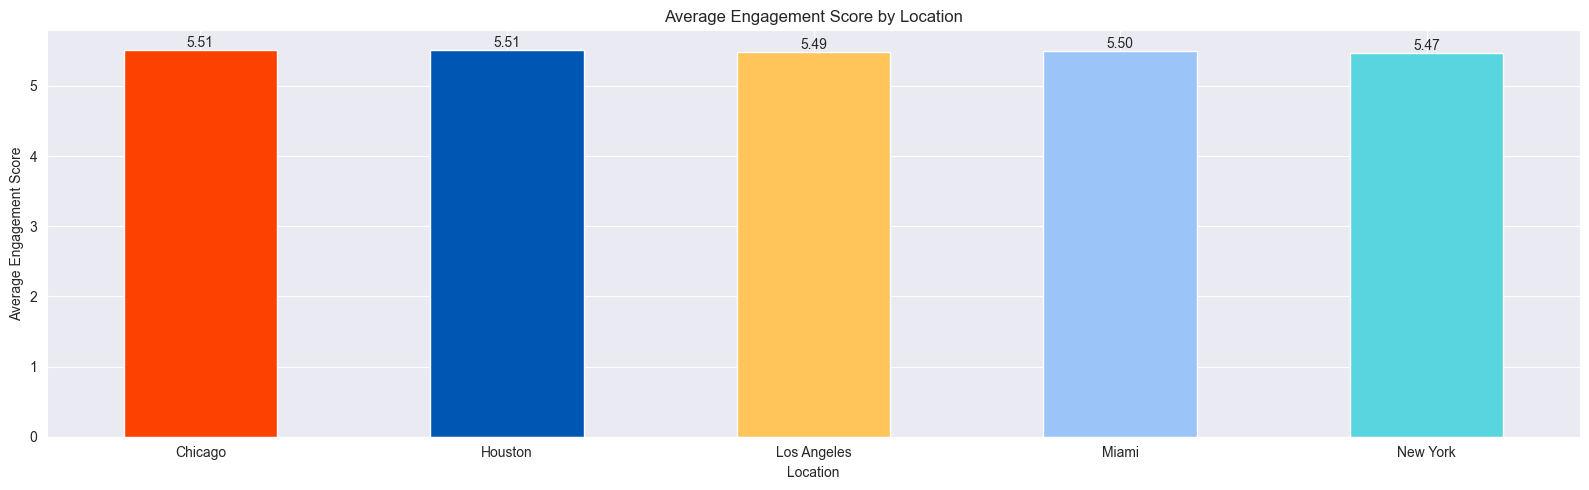

In [42]:
##  ** Location Based Campaigns Analysis **
# Average Engagement Score by Location
avg_engagement_score_by_location = df.groupby('Location')['Engagement_Score'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_engagement_score_by_location.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Engagement Score by Location')
plt.xlabel('Location')
plt.xticks(rotation=0)
plt.ylabel('Average Engagement Score')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

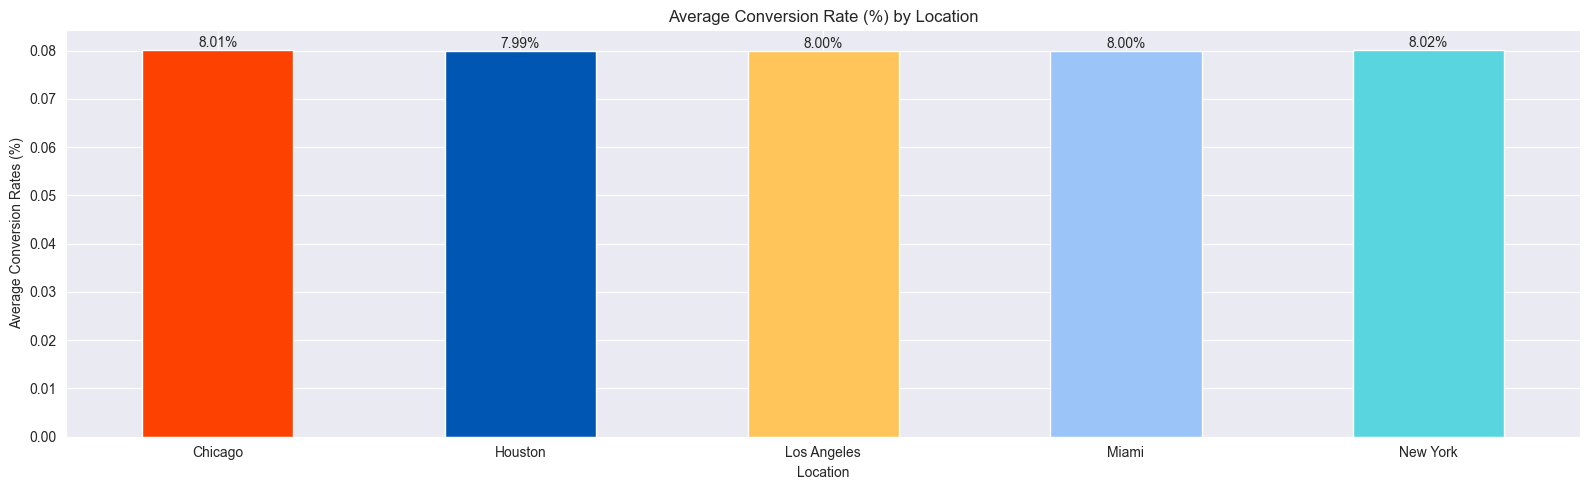

In [43]:
# Average Conversion Rates by Location
avg_conversion_rate_by_duration = df.groupby('Location')['Conversion_Rate'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_conversion_rate_by_duration.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Conversion Rate (%) by Location')
plt.xlabel('Location')
plt.xticks(rotation=0)
plt.ylabel('Average Conversion Rates (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

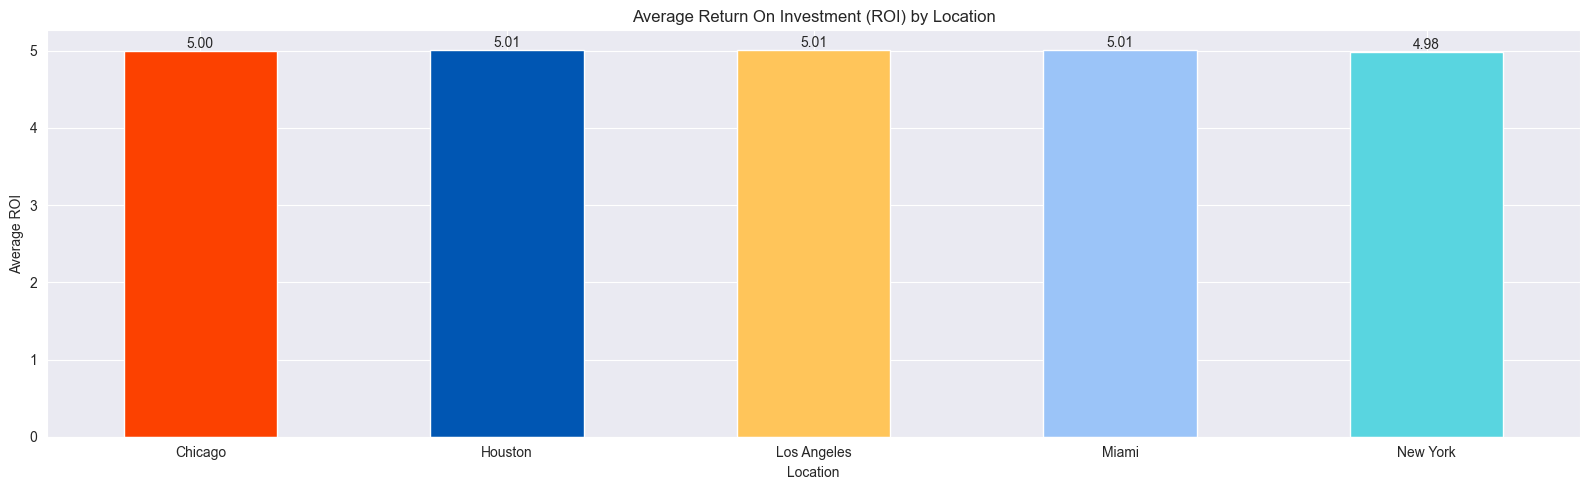

In [44]:
# Average ROI by Location
avg_roi_by_location = df.groupby('Location')['ROI'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_roi_by_location.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Return On Investment (ROI) by Location')
plt.xlabel('Location')
plt.xticks(rotation=0)
plt.ylabel('Average ROI')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

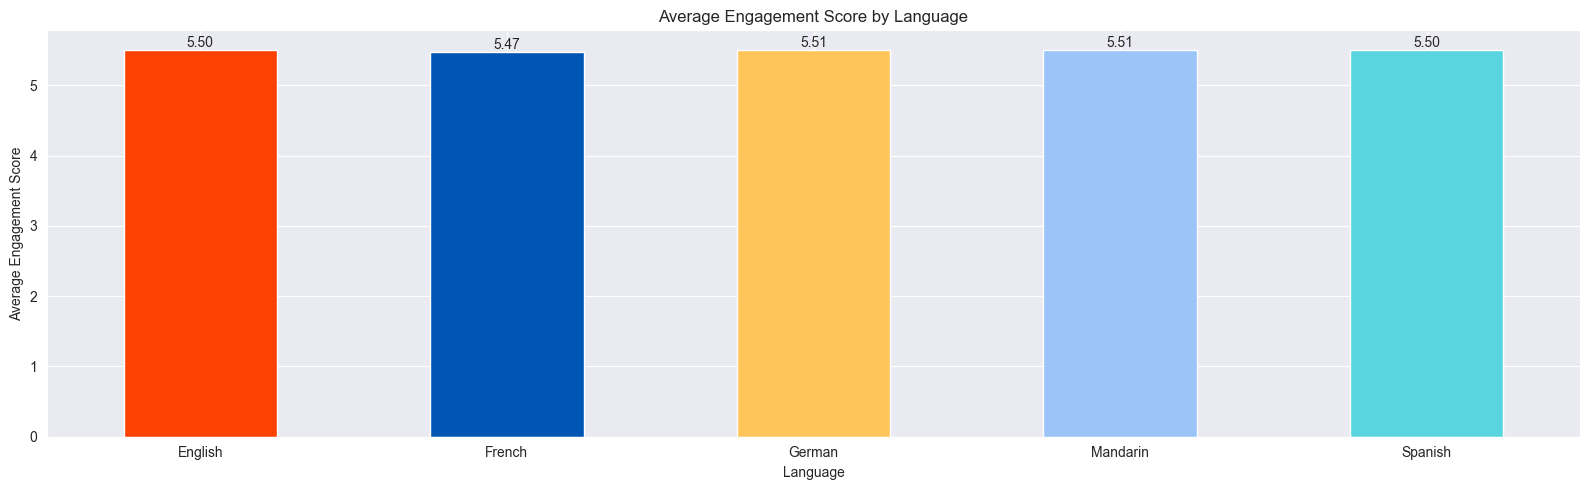

In [45]:
##  ** Language Preference Analysis **
# Average Engagement Score by Language
avg_engagement_score_by_language = df.groupby('Language')['Engagement_Score'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_engagement_score_by_language.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Engagement Score by Language')
plt.xlabel('Language')
plt.xticks(rotation=0)
plt.ylabel('Average Engagement Score')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

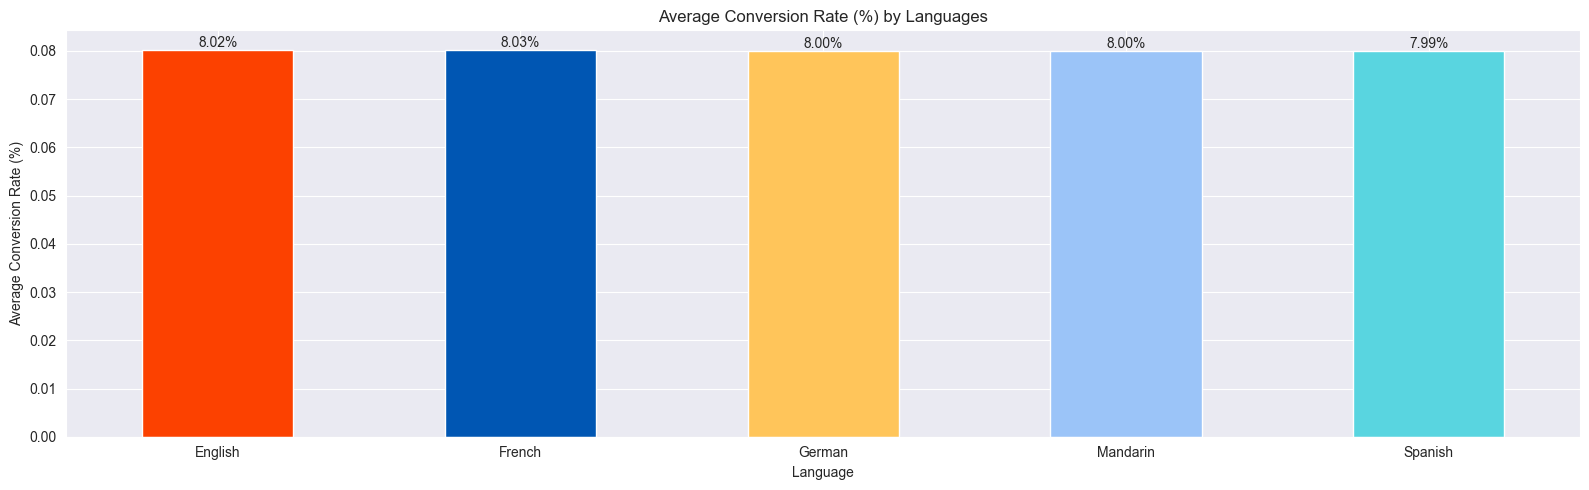

In [46]:
# Average Conversion Rates by Language
avg_conversion_rates_by_language = df.groupby('Language')['Conversion_Rate'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_conversion_rates_by_language.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Conversion Rate (%) by Languages')
plt.xlabel('Language')
plt.xticks(rotation=0)
plt.ylabel('Average Conversion Rate (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

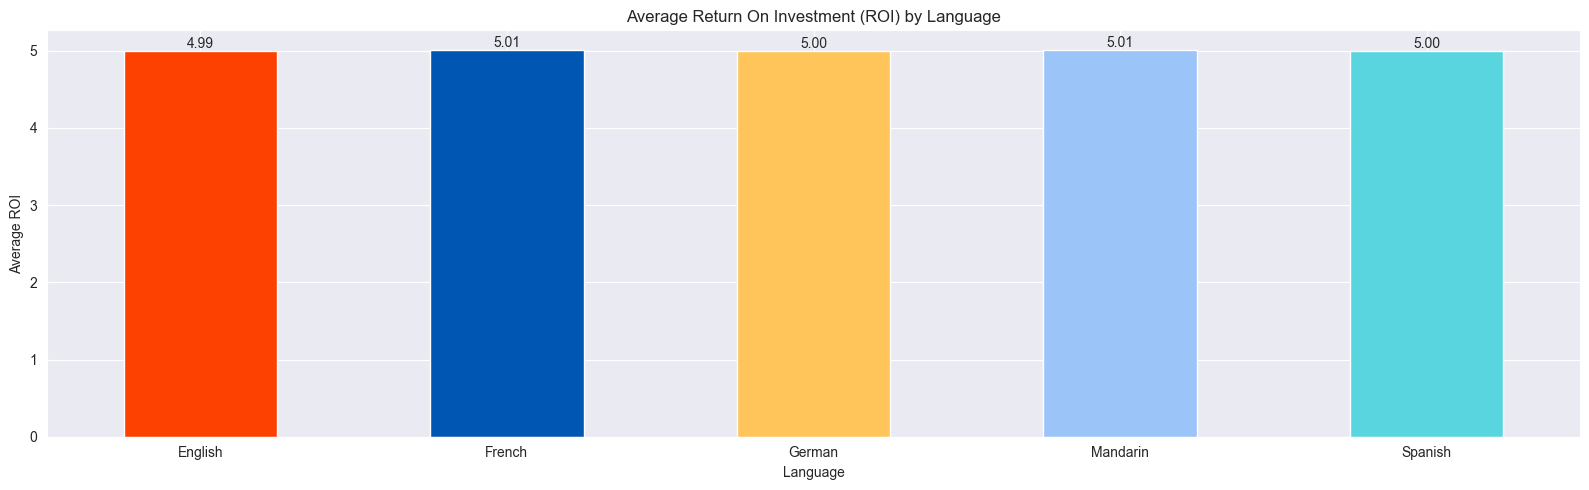

In [47]:
# Average ROI by Language
avg_roi_by_language = df.groupby('Language')['ROI'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_roi_by_language.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Return On Investment (ROI) by Language')
plt.xlabel('Language')
plt.xticks(rotation=0)
plt.ylabel('Average ROI')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

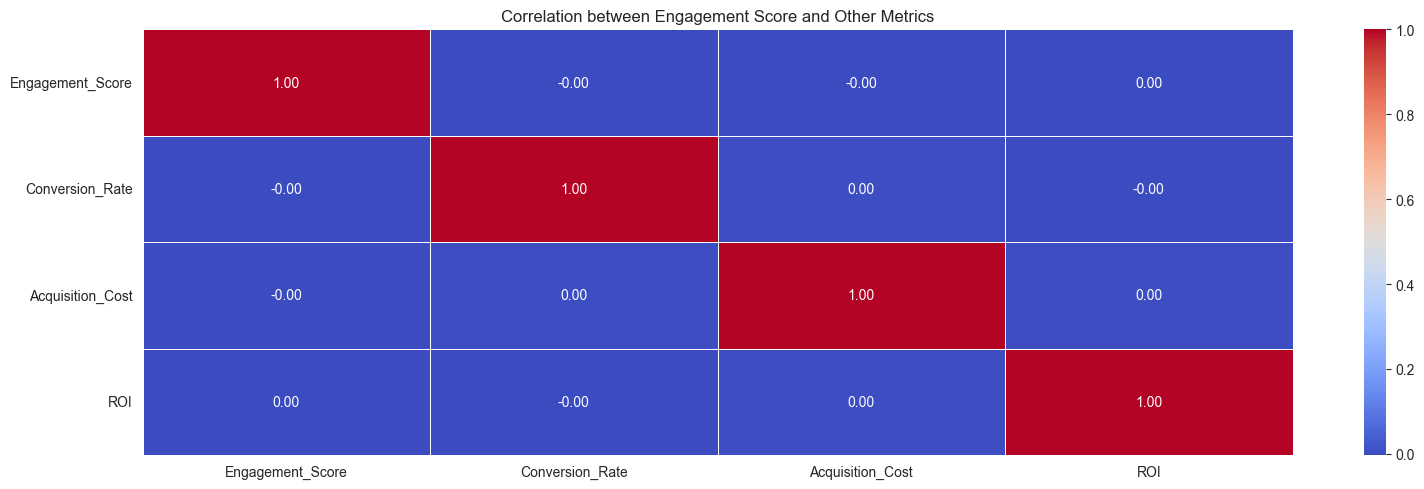

In [48]:
##  ** Engagement Scores Analysis **
# Select the relevant columns for correlation analysis
metrics = df[['Engagement_Score', 'Conversion_Rate', 'Acquisition_Cost', 'ROI']]

# Calculate the correlation matrix
correlation_matrix = metrics.corr()

# Plot the heatmap to visualize correlations
plt.figure(figsize=(16, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between Engagement Score and Other Metrics')
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

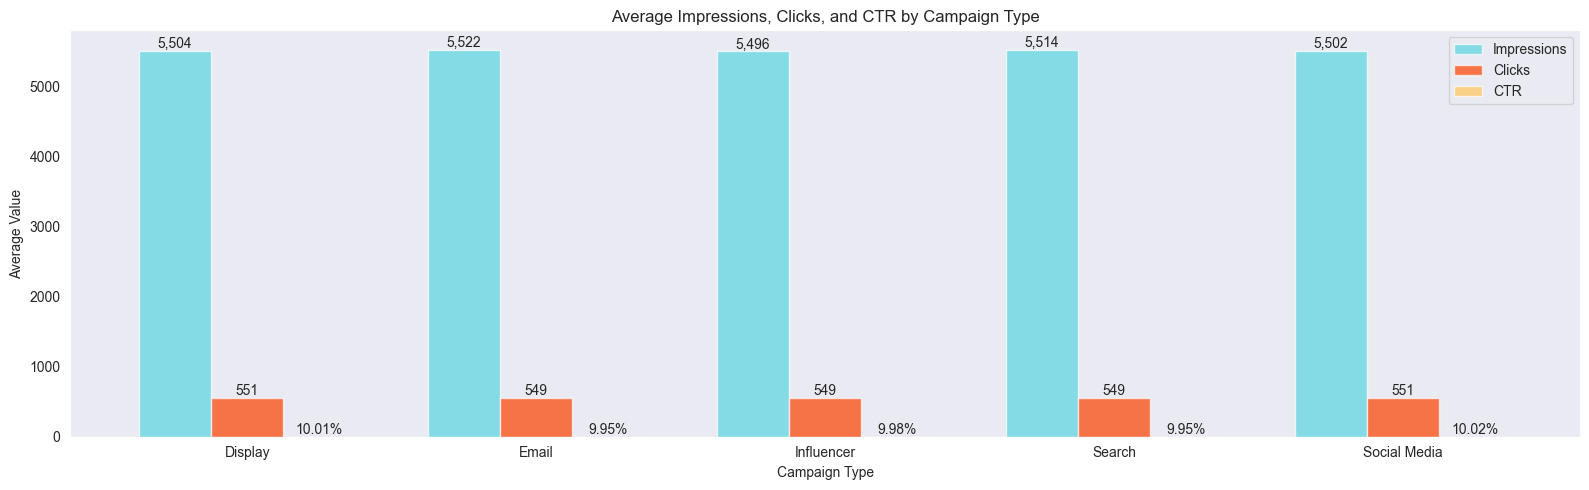

In [49]:
##  ** Clicks Vs Impressions Analysis **
# Average number of Impressions
avg_number_of_impressions = df.groupby(['Campaign_Type']).Impressions.mean()

# Average number of Clicks
avg_number_of_clicks = df.groupby(['Campaign_Type']).Clicks.mean()

# Average Click-Through Rate (CTR)
avg_ctr = avg_number_of_clicks / avg_number_of_impressions

bar_width = 0.25
index = range(len(avg_number_of_impressions))

# Plot bars for Impressions, Clicks, and CTR
plt.figure(figsize=(16, 5))
bars1 = plt.bar(index, avg_number_of_impressions, bar_width, label='Impressions', color='#59D5E0', alpha=0.7)
bars2 = plt.bar([i + bar_width for i in index], avg_number_of_clicks, bar_width, label='Clicks', color='#FC4100', alpha=0.7)
bars3 = plt.bar([i + 2 * bar_width for i in index], avg_ctr, bar_width, label='CTR', color='#FFC55A', alpha=0.7)

# Add title and labels
plt.title('Average Impressions, Clicks, and CTR by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average Value')
plt.xticks([i + bar_width for i in index], avg_number_of_impressions.index, rotation=0)

# Add data labels with condition
def add_labels(bars, is_ctr=False):
    for bar in bars:
        height = bar.get_height()
        label = f'{height:.2%}'
        if not is_ctr:
            label = f'{height:,.0f}'
        plt.text(bar.get_x() + bar.get_width() / 2, height, label, ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3, is_ctr=True)

# Disable grid
plt.grid(False)

# Legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [50]:
##  ** Temporal Trends **
# Extract year and month for temporal analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Aggregate data by month to analyze campaign performance over time
campaign_monthly_performance = df.groupby(['Year', 'Month']).agg({
    'Engagement_Score': 'mean',
    'Conversion_Rate': 'mean',
    'ROI': 'mean'
}).reset_index()

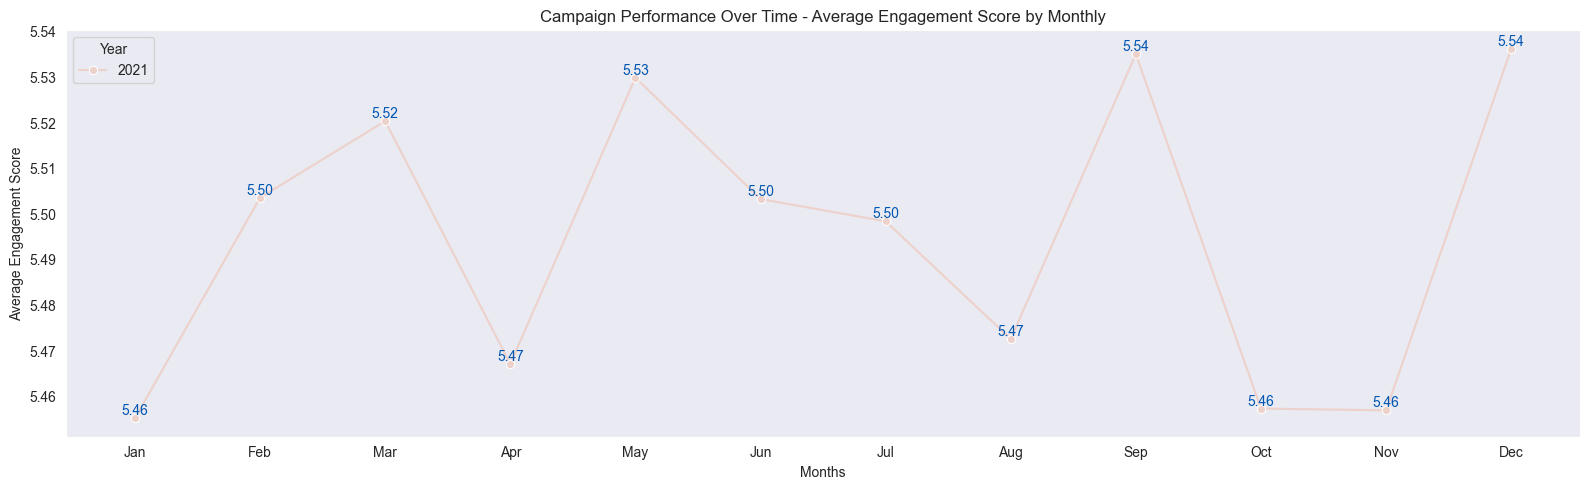

In [51]:
# Lineplot for Average Engagement Score
plt.figure(figsize=(16, 5))
lineplot = sns.lineplot(x='Month', y='Engagement_Score', hue='Year', data=campaign_monthly_performance, marker='o')

# Adding data labels to each point
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data,
                 y_data,
                 f'{y_data:.2f}',
                 ha='center',
                 va='bottom',
                 color='#0056B3')

# Add title and labels
plt.title('Campaign Performance Over Time - Average Engagement Score by Monthly')
plt.xlabel('Months')
plt.ylabel('Average Engagement Score')

# Show month names on x-axis
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Disable grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

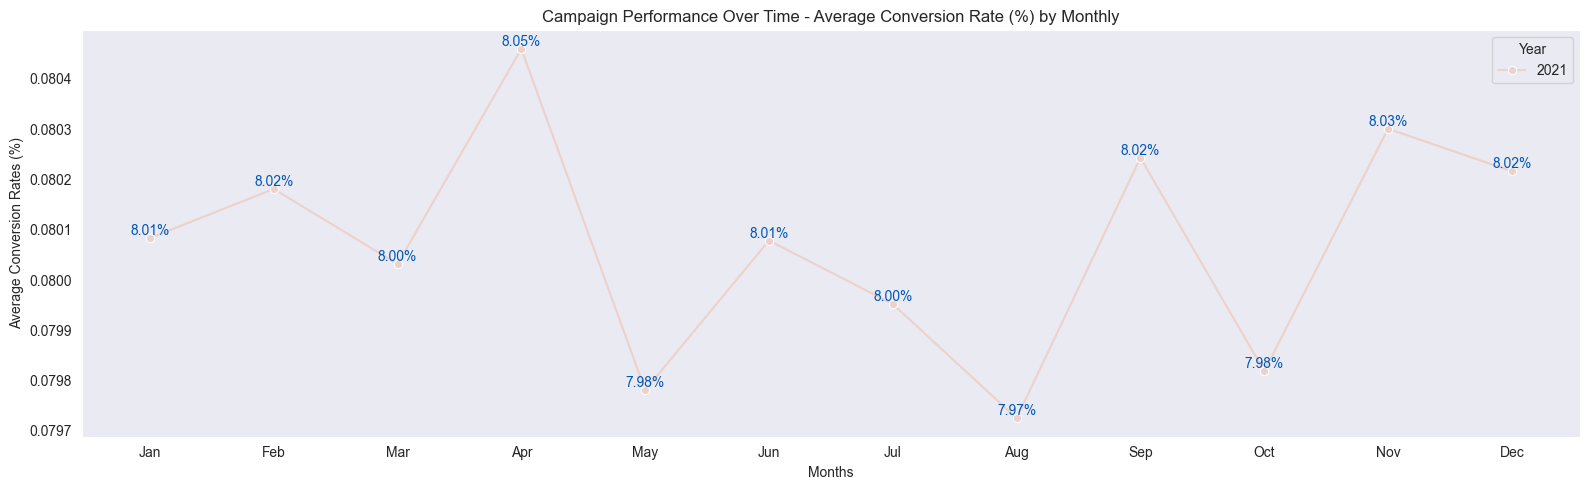

In [52]:
# Lineplot for Average Conversion Rate
plt.figure(figsize=(16, 5))
lineplot = sns.lineplot(x='Month', y='Conversion_Rate', hue='Year', data=campaign_monthly_performance, marker='o')

# Adding data labels to each point
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data,
                 y_data,
                 f'{y_data:.2%}',
                 ha='center',
                 va='bottom',
                 color='#0056B3')

# Add title and labels
plt.title('Campaign Performance Over Time - Average Conversion Rate (%) by Monthly')
plt.xlabel('Months')
plt.ylabel('Average Conversion Rates (%)')

# Show month names on x-axis
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Disable grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

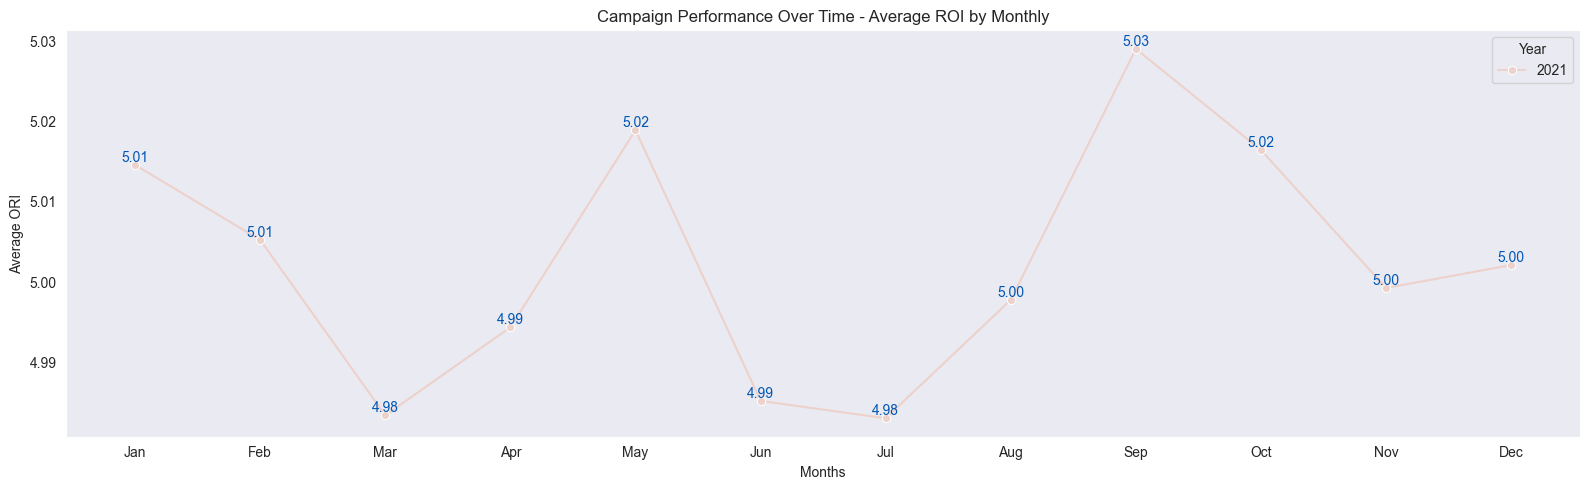

In [53]:
# Lineplot for Average ORI
plt.figure(figsize=(16, 5))
lineplot = sns.lineplot(x='Month', y='ROI', hue='Year', data=campaign_monthly_performance, marker='o')

# Adding data labels to each point
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data,
                 y_data,
                 f'{y_data:.2f}',
                 ha='center',
                 va='bottom',
                 color='#0056B3')

# Add title and labels
plt.title('Campaign Performance Over Time - Average ROI by Monthly')
plt.xlabel('Months')
plt.ylabel('Average ORI')

# Show month names on x-axis
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Disable grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

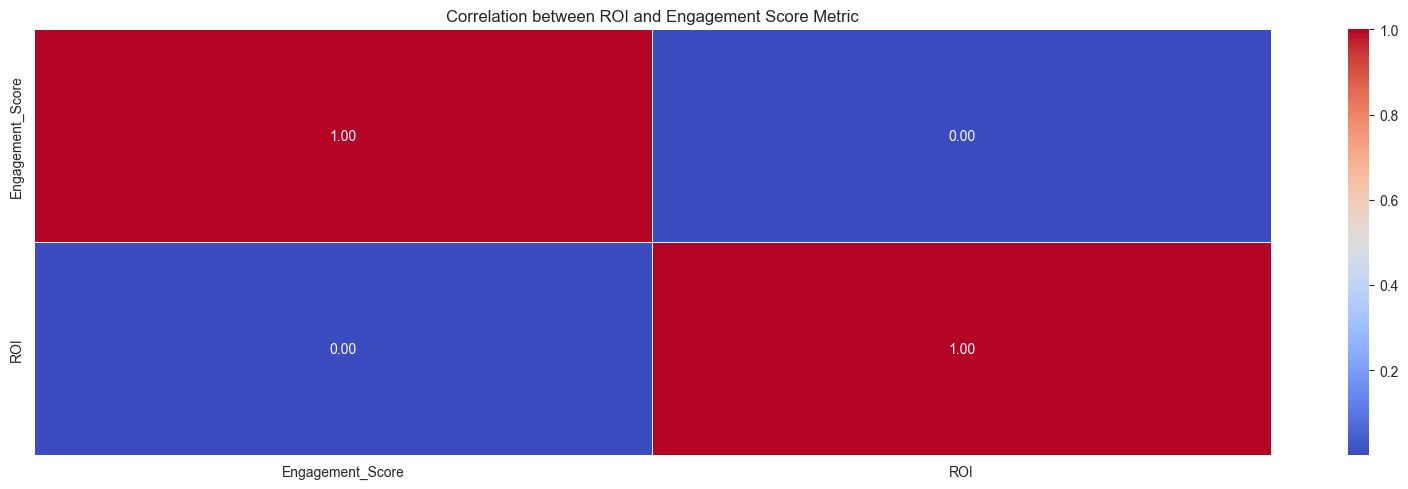

In [54]:
##  ** ROI vs. Engagement Socre Analysis **
# Select the relevant columns for correlation analysis
engagement_score_and_roi_metrics = df[['Engagement_Score', 'ROI']]

# Calculate the correlation matrix
correlation_engagement_score_and_roi_metrics = engagement_score_and_roi_metrics.corr()

# Plot the heatmap to visualize correlations
plt.figure(figsize=(16, 5))
sns.heatmap(correlation_engagement_score_and_roi_metrics, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between ROI and Engagement Score Metric')
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()


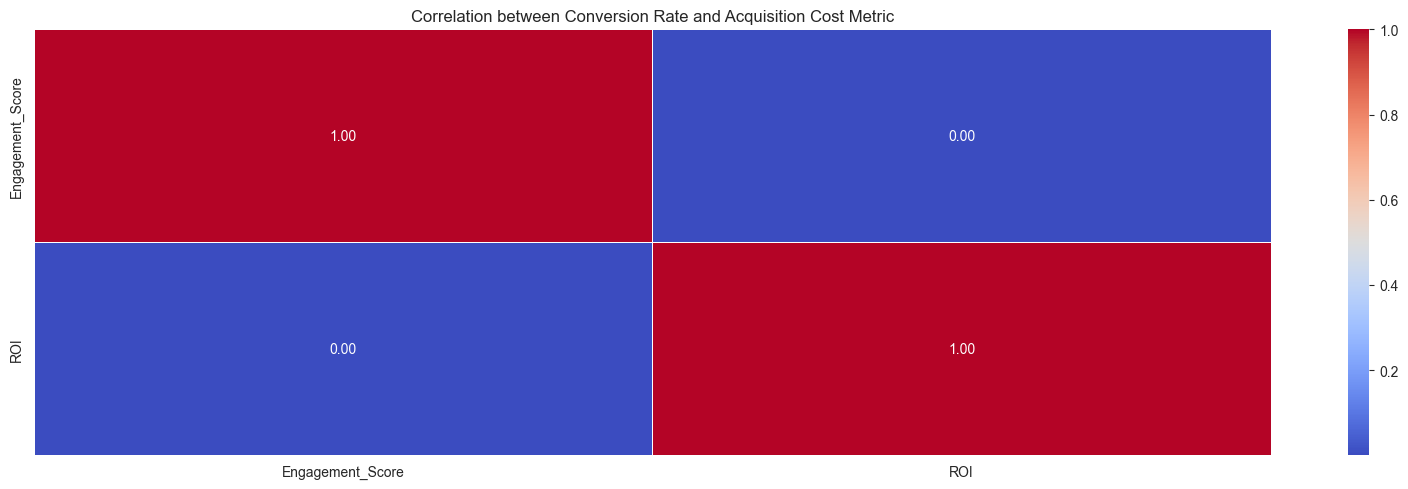

In [55]:
##  ** Conversion Rate vs. Acquisition Cost **
# Select the relevant columns for correlation analysis
conversion_rate_and_acquisition_cost_metrics = df[['Conversion_Rate', 'Acquisition_Cost']]

# Calculate the correlation matrix
conversion_rate_and_acquisition_cost_metrics = engagement_score_and_roi_metrics.corr()

# Plot the heatmap to visualize correlations
plt.figure(figsize=(16, 5))
sns.heatmap(correlation_engagement_score_and_roi_metrics, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between Conversion Rate and Acquisition Cost Metric')
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()